
II. Likelihood and Estimation (15 points) What you should do:

ˆ Specify a statistical model (e.g., Bernoulli, Normal, Logistic)

ˆ Write down the likelihood function (conceptually or mathematically)

ˆ Compute or estimate parameters using MLE

ˆ Visualize or interpret how the likelihood behaves


Connection to class: Likelihood lectures + Lab 3

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Total patients: 101766
Readmitted patients: 46902
MLE (p̂): 0.4609


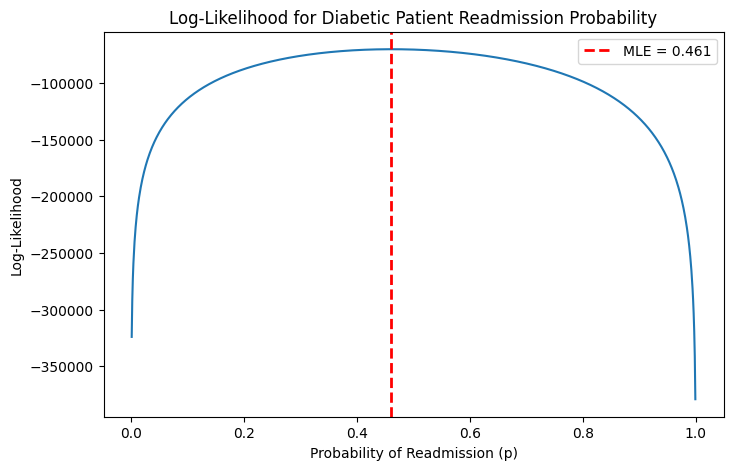

In [5]:
# Load data
data = pd.read_csv("finaldiabetes.csv")

# Ensure binary column exists
if "readmitted_binary" not in data.columns:
    data["readmitted_binary"] = np.where(data["readmitted"] == "NO", 0, 1)

# Data setup
y = data["readmitted_binary"]
n = len(y)
x = y.sum()

# MLE
p_hat = x / n

# Results
print("Total patients:", n)
print("Readmitted patients:", x)
print("MLE (p̂):", round(p_hat, 4))

# Likelihood values
p_values = np.linspace(0.001, 0.999, 1000)
log_likelihood = x * np.log(p_values) + (n - x) * np.log(1 - p_values)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(p_values, log_likelihood)
plt.axvline(p_hat, linestyle="--", color="red", linewidth=2, label=f"MLE = {p_hat:.3f}")
plt.xlabel("Probability of Readmission (p)")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood for Diabetic Patient Readmission Probability")
plt.legend()

plt.savefig("likelihood_plot.png")
plt.show()

### Interpretation of Estimator Properties

The MLE for \( p \) is \( \hat{p} = 0.461 \), which means the estimated probability of readmission in this sample is about 46.1%. Since this estimator is the sample proportion, it is easy to interpret and directly reflects the observed rate of readmission in the dataset. Because the sample size is very large, the estimator should have relatively low sampling variability, meaning repeated samples of similar size would likely produce estimates close to this value. The likelihood curve is also sharply centered around \( \hat{p} \), which supports the idea that values far from 0.461 are less consistent with the observed data.